# Similarity between subcellular regions

The `rs` (region similarity) module provides metrics to assess how well subcellular regions (e.g. cell and nucleus) align. 

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

sdata = sd.read_zarr("../../data/xenium_sdata.zarr/")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: Fut

Next, the `SegTraQ` object is initialized.

In [3]:
st = segtraq.SegTraQ(
    sdata,
    images_key="image",  # where the image is stored
    tables_centroid_x_key="x_centroid",  # where the x centroid is stored
    tables_centroid_y_key="y_centroid",  # where the y centroid is stored
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1317: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(


The `spatialdata`dataset contains cell and nuclear masks as `Shapes`and `Labels`, as shown below.

## Intersection over Union between cell and nucleus masks

First, we get the nucleus that overlaps most with each cell and compute the Intersection over Union (IoU) between cell and nuclear masks using the method `match_nuclei_to_cells`. It is applicable only when nuclear masks are available.

In [4]:
import time

n = 1

start = time.time()
results_df = st.rs.match_nuclei_to_cells(n_jobs=n)
end = time.time()

print(f"Elapsed time with {n} threads: {end - start:.2f} seconds")

Elapsed time with 1 threads: 18.86 seconds


In [5]:
results_df

,cell_id,nucleus_id,IoU,nucleus_fraction
0,acceakgj-1,0.0,0.617026,1.000000
1,accebped-1,1.0,0.556906,0.999997
2,accedpdh-1,2.0,0.427579,0.997749
3,acceejoe-1,3.0,0.708851,1.000000
4,acceekkh-1,4.0,0.543778,1.000000
...,...,...,...,...
18306,oendojhd-1,18603.0,1.000000,1.000000
18307,oenebcdp-1,18604.0,0.315779,1.000000
18308,oenebphn-1,18605.0,1.000000,1.000000
18309,oeneegja-1,18606.0,1.000000,1.000000


For each `cell_id`, we obtain the ID (`best_nuc_id`) of the nucleus mask with the highest `IoU`. If a cell does not overlap with any nucleus, the function returns a missing value for `best_nuc_id`. If the nucleus has an invalid geometry, `IoU`is reported as `NA`.

In the spatial plots, we can see that cells that have a high overlap with nuclei, also show a high IoU value. 

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


WARNING  Found 184 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
WARNING  Found 184 NaN values in color data. These observations will be 

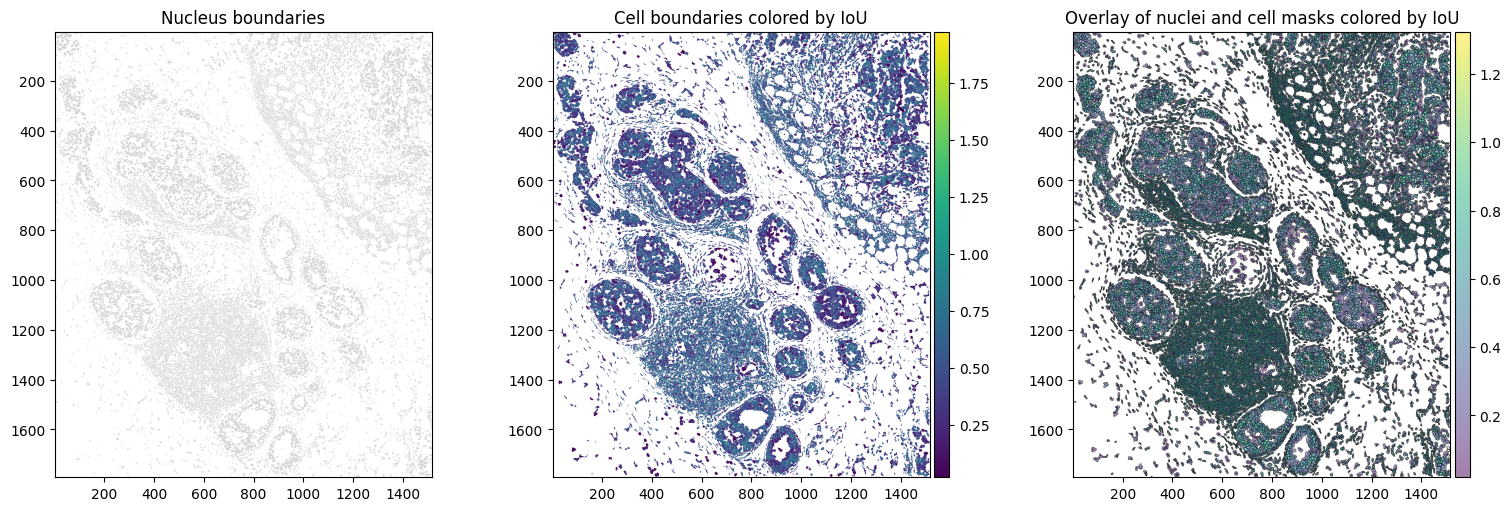

In [6]:
axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)[1].flatten()

# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# plot
sdata.pl.render_shapes("nucleus_boundaries").pl.show(
    ax=axes[0], title="Nucleus boundaries", coordinate_systems="global"
)

sdata.pl.render_shapes("cell_boundaries", color="IoU").pl.show(
    ax=axes[1], title="Cell boundaries colored by IoU", coordinate_systems="global"
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="IoU",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=axes[2], title="Overlay of nuclei and cell masks colored by IoU", colorbar=True)

The histogram of IoU distribution (below) shows a median IoU is at 0.53, i.e. 53% overlap. 

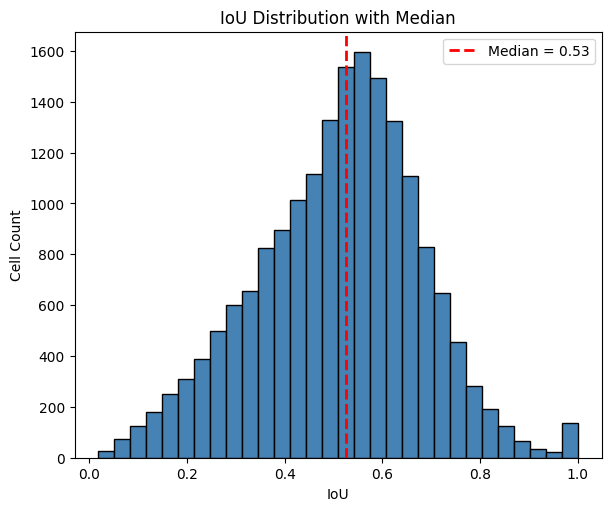

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare IoU values
ious = sdata["table"].obs["IoU"].dropna()
median_iou = np.median(ious)

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(ious, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_iou,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_iou:.2f}",
)

# Decorate
ax.set_title("IoU Distribution with Median")
ax.set_xlabel("IoU")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

## Expression similarity between cell and nucleus

Expression similarity between a cell and the "most-overlapping" nucleus can be computed using `similarity_nucleus_cell()`. It is applicable only when nuclear masks are available. 

In [8]:
similarity_df = st.rs.similarity_nucleus_cell(metric="cosine_sim")

The histogram below shows the distribution of cosine similarity values across cells. It is right-skewed, with a median of 0.77. This provides intuition about possible spatial spillover: cells may be contaminated by neighboring cells, assuming that nuclei capture expression with less contamination due to their smaller radius.

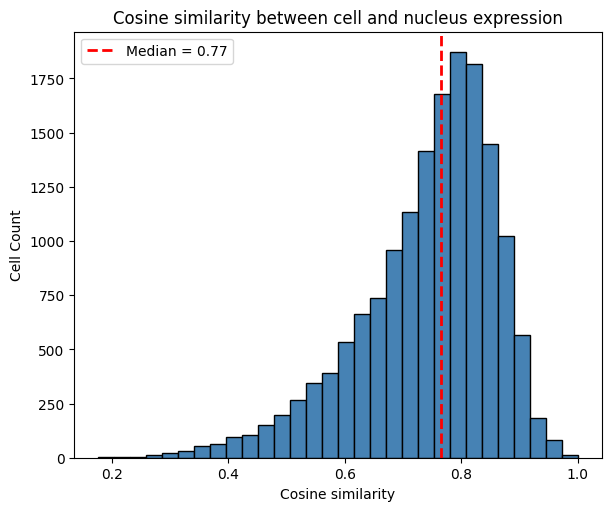

In [9]:
# Prepare similarity values
obs = sdata["table"].obs
similarities = obs["similarity_nucleus_cell"].dropna()
median_similarity = np.median(similarities)

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(similarities, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_similarity,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_similarity:.2f}",
)

# Decorate
ax.set_title("Cosine similarity between cell and nucleus expression")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The calculated R2 (coefficient of determination) is 0.429 indicating that similarity/correlation between cell and nucleus increases with their IoU. 

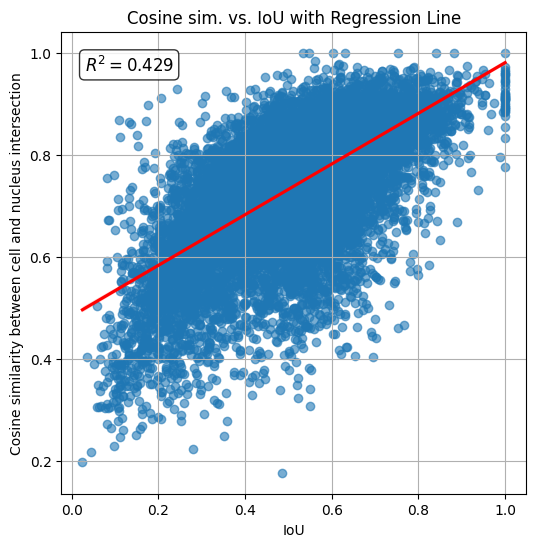

In [10]:
import seaborn as sns
from scipy.stats import linregress

# Extract the relevant columns, excluding NaNs
df = obs[["IoU", "similarity_nucleus_cell"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["IoU"], df["similarity_nucleus_cell"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="IoU",
    y="similarity_nucleus_cell",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("IoU")
ax.set_ylabel("Cosine similarity between cell and nucleus intersection")
ax.set_title("Cosine sim. vs. IoU with Regression Line")
ax.grid(True)

plt.show()

The spatial plot below overlays nucleus boundaries, cell masks colored by cosine similarity, and transcripts. Cells whose transcripts are distributed across the nucleus region tend to have higher correlation with the nucleus, while cells whose transcripts are localized outside the nuclear region—potentially due to spillover from neighboring cells—tend to exhibit lower correlation.

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
WARNING  Found 2437 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
WARNING  Found 184 NaN values in color data. These observations will be 

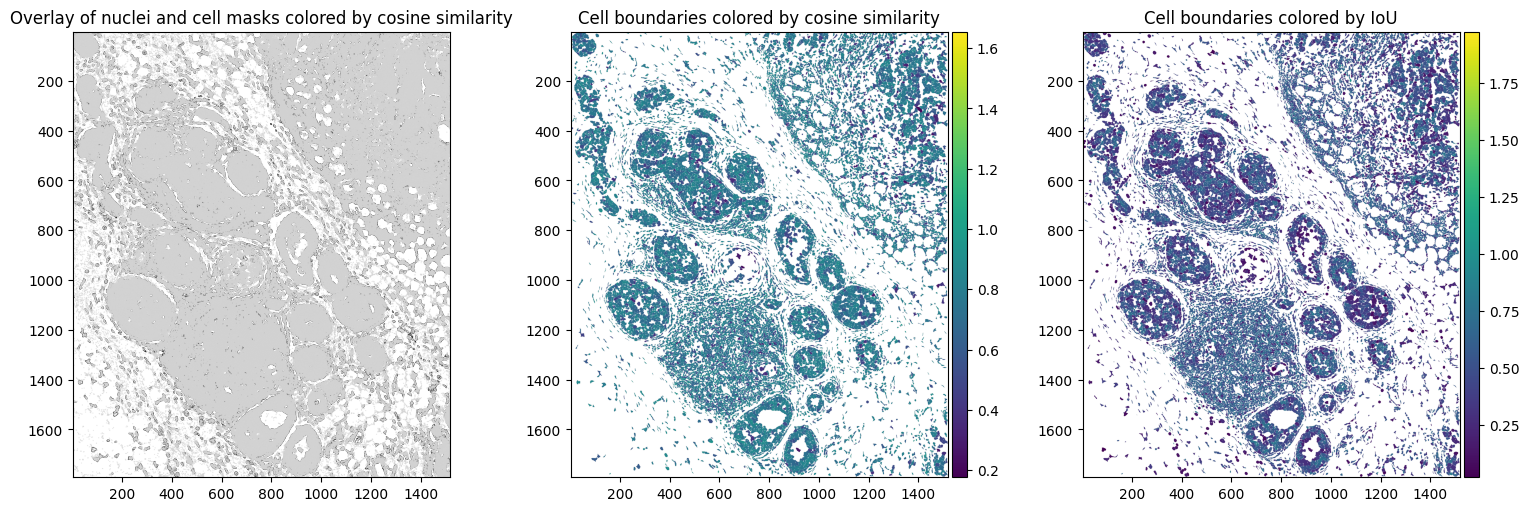

In [11]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_nc_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2", "CD44", "PTPRC"],
    palette=["red", "red", "red"],
).pl.show(
    ax=axes[0],
    title="Overlay of nuclei and cell masks colored by cosine similarity",
    colorbar=True,
    figsize=(6, 6),
)


sdata.pl.render_shapes("cell_boundaries", color="similarity_nucleus_cell").pl.show(
    ax=axes[1], title="Cell boundaries colored by cosine similarity", coordinate_systems="global"
)

sdata.pl.render_shapes("cell_boundaries", color="IoU").pl.show(
    ax=axes[2], title="Cell boundaries colored by IoU", coordinate_systems="global"
)

We can see that there are some cells with high `similarity_nucleus_cell` despite low `IoU` and `nucleus_fraction`, such as cell `11399`.

In [25]:
df = obs[["IoU", "nucleus_fraction", "similarity_nucleus_cell"]].dropna().reset_index()
df.columns = ["cell", "IoU", "nucleus_fraction", "similarity_nucleus_cell"]
df.loc[df["IoU"] < 0.1].sort_values("similarity_nucleus_cell", ascending=False).head(10)

,cell,IoU,nucleus_fraction,similarity_nucleus_cell
15868,18276,0.097772,1.000000,0.760886
15832,18142,0.080972,1.000000,0.753778
5281,5674,0.086590,1.000000,0.671867
15872,18303,0.083144,1.000000,0.671827
15828,18135,0.099064,1.000000,0.651584
10948,12510,0.082200,1.000000,0.591359
6909,7597,0.081123,1.000000,0.577960
15822,18108,0.058807,1.000000,0.502759
12659,14429,0.087156,1.000000,0.485765
10035,11399,0.079194,0.999247,0.479855


Let's investigate this cell in more detail. By plotting the cell (centroid marked by grey cross) with its nucleus (centroid marked by black cross) and assigned transcripts (red), we can see that for this cell, all of its transcripts lie outside the cell boundary, which is possible due to the transcript repositioning capabilities of proseg. The nucleus gets assigned to this cell because it intersects its boundary, however, the intersecting area is very low.

In [31]:
cid = (
    df.loc[df["IoU"] < 0.1]
    .dropna(subset=["similarity_nucleus_cell"])
    .sort_values("similarity_nucleus_cell", ascending=False)
    .iloc[0]["cell"]
)
cid

'18276'

In [32]:
def plot_cell_with_nucleus_and_transcripts(
    cid: float | int, title: str, pix_to_um_scale_factor: float = 0.2125, repositioned_transcripts: bool = False
):
    # add annotation of this cell to .obs
    sdata["table"].obs["focal_cell"] = sdata["table"].obs.index == cid

    # compute x,y of cell and nucleus centroids in µm space
    print(sdata["cell_boundaries"])
    centroid_x_cell = sdata["cell_boundaries"].loc[cid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_cell = sdata["cell_boundaries"].loc[cid].geometry.centroid.y / pix_to_um_scale_factor

    nid = sdata["table"].obs.loc[sdata["table"].obs["cell"] == cid, "best_nuc_id"]
    centroid_x_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y / pix_to_um_scale_factor

    # add annotation of this cell to .points and build new `PointsModel``
    trans = sdata.points["transcripts"].compute()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans["assignment"] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")
    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"])
        trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})
    sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points["transcripts"])
    sd.transformations.set_transformation(sdata.points["transcripts_2"], T)

    # plot cell and transcripts of that cell
    axes = plt.subplots(1, 1, figsize=(16, 16), constrained_layout=True)[1]

    sdata.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color="focal_cell",
        fill_alpha=0.1,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="blue",
    ).pl.render_points(
        "transcripts_2",
        color="focal_cell",
        fill_alpha=0.1,
        groups=["focal_cell"],
        palette=["red"],
    ).pl.show(
        ax=axes,
        title=title,
        colorbar=True,
        figsize=(10, 10),
    )

    # landmark for cell and nucleus centroid
    axes.scatter([centroid_x_cell], [centroid_y_cell], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)
    axes.scatter([centroid_x_nucleus], [centroid_y_nucleus], marker="+", s=400, c="black", linewidths=2, zorder=10)

In [34]:
# TODO: REACTIVATE
# plot_cell_with_nucleus_and_transcripts(cid, title="Cell with high corr_nc_cell despite high IoU")

Instead of the true (raw) coordinates, we can also plot the repositioned coordinates of transcripts, which shows that proseg places them inside the cell. 

In [35]:
#plot_cell_with_nucleus_and_transcripts(
#    cid, repositioned_transcripts=True, title="Cell with high corr_nc_cell despite high IoU"
#)

Such cells can be identified easily via the metric `perc_points_outside_border`, which comptues the percentage of transcripts that are assigned to a cell, but localized outside its border.

In [35]:
# st.ps.perc_points_outside_boundary()


KeyboardInterrupt



KeyboardInterrupt: 

We can see that cell `70505` appears among the cells with the highest percentage of transcripts outside the cell. 

In [ ]:
# sdata["table"].obs.sort_values("pct_points_outside", ascending=False)

As a more specific metric, we therefore compute the correlation between the transcripts in the cell region intersecting the nucleus and the transcripts in the remaining cell region. 

## Similarity between Nucleus and Cytoplasm

The function `similarity_nucleus_cytoplasm()` computes the cosine similarity between the spatial transcript feature counts within the nucleus and the cytoplasm. It is applicable only when nuclear masks are available. It returns `NaN` when the regions have no or not a sufficient number of overlapping transcripts (`min_transcripts`, `min_genes`). A low correlation/similarity may indicate that the cell boundary extension captures neighborhood or ambient signal rather than true intracellular expression—a concern similarly highlighted by segmentation benchmarks such as [Baysor](https://www.nature.com/articles/s41587-021-01044-w). This is based on the assumption that transcripts are homogeneously distributed within the cell and not localized in specific subcellular regions. 

In [36]:
sim_nuc_cyto_df = st.rs.similarity_nucleus_cytoplasm(metric="cosine_sim")

ERROR! Session/line number was not unique in database. History logging moved to new session 14684


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/rs/region_similarity.py:495: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([points_cell_id_key, points_gene_key])
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/rs/region_similarity.py:504: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([points_cell_id_key, points_gene_key])


In [38]:
sim_nuc_cyto_df.head()

,cell_id,nucleus_id,IoU,nucleus_fraction,similarity_nucleus_cytoplasm
0,acceakgj-1,0.0,0.617026,1.000000,0.050798
1,accebped-1,1.0,0.556906,0.999997,0.042276
2,accedpdh-1,2.0,0.427579,0.997749,0.044994
3,acceejoe-1,3.0,0.708851,1.000000,NaN
4,acceekkh-1,4.0,0.543778,1.000000,0.035391


The histogram below shows that the cosine similarity between the intersection and remainder region of the cell is 0.47. 

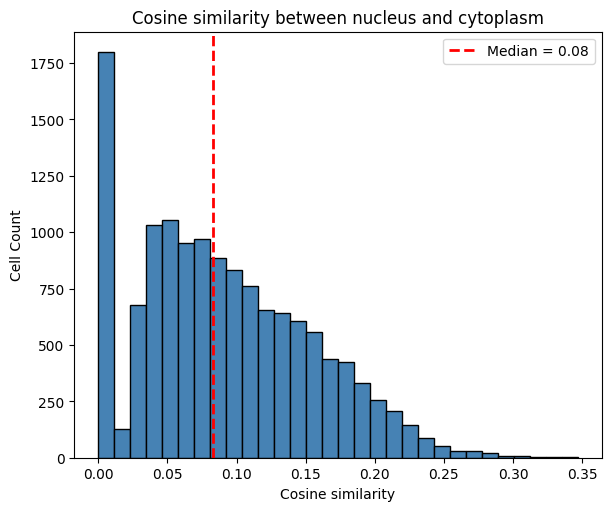

In [40]:
obs = sdata["table"].obs
# Prepare corr_parts values
sim_nuc_cyto_df = obs["similarity_nucleus_cytoplasm"].dropna()
median_sim_nuc_cyto = sim_nuc_cyto_df.median()

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(sim_nuc_cyto_df, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_sim_nuc_cyto,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_sim_nuc_cyto:.2f}",
)

# Decorate
ax.set_title("Cosine similarity between nucleus and cytoplasm")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The scatter plot below visualizes the cosine similarity between transcript counts in the intersection and remainder of each cell, plotted against the Intersection over Union (IoU) with the nucleus. The calculated R2 value is 0.006, indicating that `similarity_nucleus_cytoplasm` is independent of `IoU`.

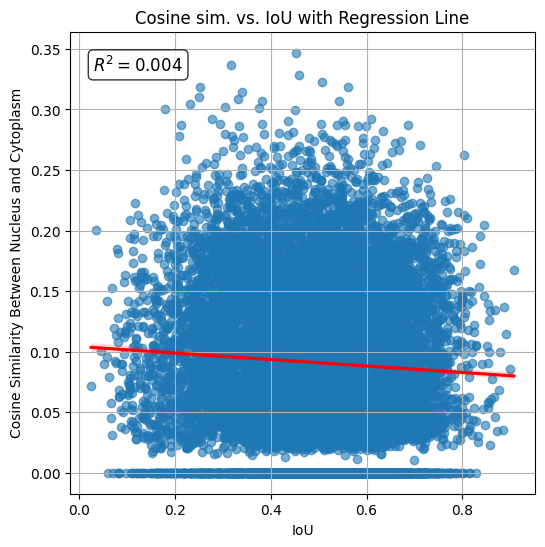

In [41]:
import seaborn as sns

# Extract the relevant columns, excluding NaNs
df = obs[["IoU", "similarity_nucleus_cytoplasm"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["IoU"], df["similarity_nucleus_cytoplasm"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="IoU",
    y="similarity_nucleus_cytoplasm",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("IoU")
ax.set_ylabel("Cosine Similarity Between Nucleus and Cytoplasm")
ax.set_title("Cosine sim. vs. IoU with Regression Line")
ax.grid(True)

plt.show()

The spatial plots below shows the spatial distribution of computed correlations. The cosine similarity between parts can be a measure of how much neighboring signal is captured. 

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


WARNING  Found 184 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using 'datashader' backend with 'None' as reduction method to s

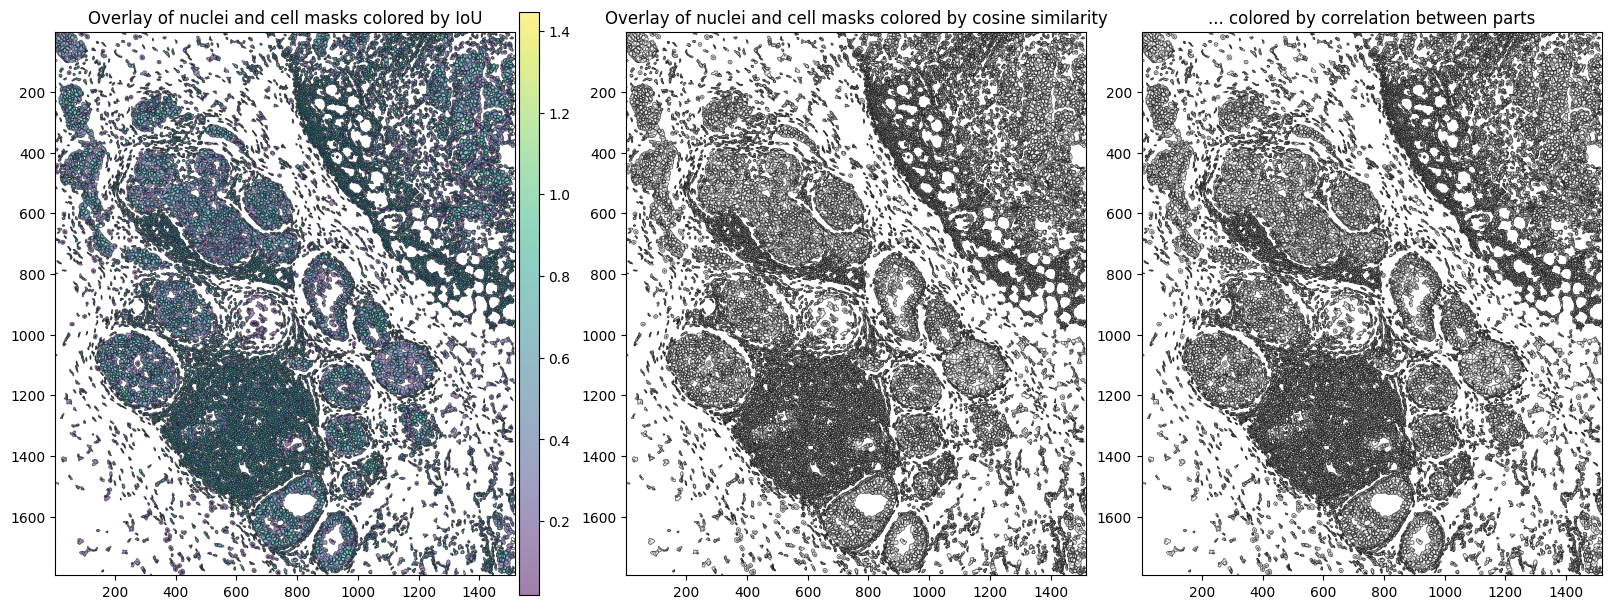

In [42]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="IoU",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[0],
    title="Overlay of nuclei and cell masks colored by IoU",
    colorbar=True,
    figsize=(6, 6),
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_nc_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[1],
    title="Overlay of nuclei and cell masks colored by cosine similarity",
    colorbar=True,
    figsize=(6, 6),
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="correlation_parts",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[2],
    title="... colored by correlation between parts",
    colorbar=True,
    figsize=(6, 6),
)

Above, we can see that there are some cells with low cosine similarity between parts despite high `IoU`. Let's investigate these. We can see that this happens when the transcripts are only localized in the nucleus but not in the cytoplasm or vice versa.

In [43]:
#cid = obs.loc[obs["IoU"] > 0.5].dropna(subset=["similarity_nucleus_cytoplasm"]).sort_values("similarity_nucleus_cytoplasm").iloc[0]["cell"]

In [44]:
#plot_cell_with_nucleus_and_transcripts(cid, title="Cell with low cosine similarity between parts despite high IoU")

## Similarity between the cell border with its neigbhorhood
The function `similarity_nucleus_cytoplasm()` computes the cosine similarity between (1) the cell border and an eroded interior and (2) the cell border and the immediate neighborhood.

Specifically, the function:
1. Erodes each cell polygon to obtain a center region.
2. Defines the border region as the set difference between the full cell
   and its eroded center.
3. Computes gene expression profiles for center and border.
4. Computes the correlation between center and border expression.
5. Computes the correlation between border expression and the
   neighborhood expression profile.
6. The ratio of the latter two

In [45]:
border_nhood_df = st.rs.similarity_border_neighborhood()

In [46]:
border_nhood_df.head()

,cell_id,similarity_center_border,similarity_border_neighborhood,ratio_border_neighborhood_to_center
0,acceakgj-1,0.091307,0.090502,0.991186
1,accebped-1,0.125517,0.094898,0.756057
2,accedpdh-1,0.189379,0.060705,0.320548
3,acceejoe-1,0.086407,0.160666,1.859408
4,acceekkh-1,0.143825,0.094464,0.656798


The histogram below shows the distribution of the correlation between the cell center and border.

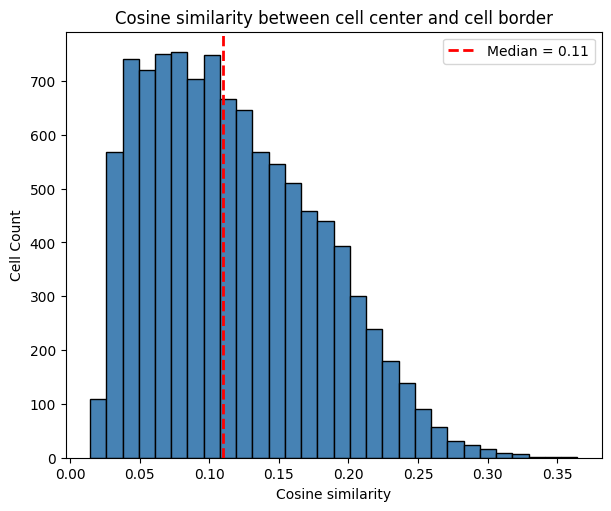

In [48]:
similarities = sdata["table"].obs["similarity_center_border"].dropna()
median_similarity = np.median(similarities)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.hist(similarities, bins=30, color="steelblue", edgecolor="black")
ax.axvline(
    median_similarity,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_similarity:.2f}",
)

ax.set_title("Cosine similarity between cell center and cell border")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cell Count")
ax.legend()
plt.show()

The histogram below shows the distribution of the correlation between the cell border and its neigbhorhood (with a distance of twice cell radius from its centroid). As expected, the correlation to the cell center is higher than to the cell neighborhood. This will differ depending on whether the cell is located within a homogeneous or a heterogeneous neighborhood.

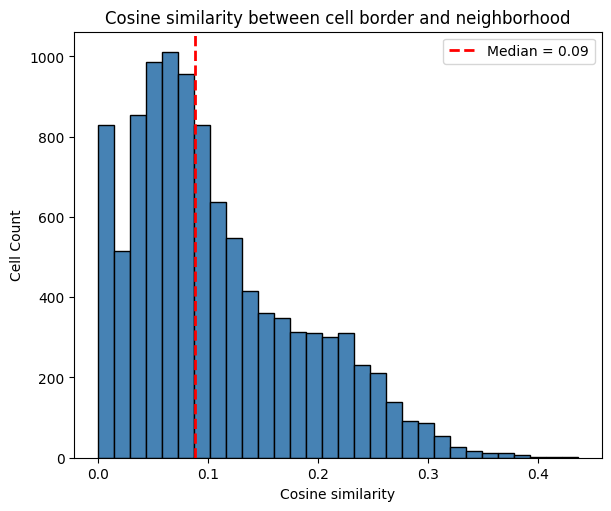

In [49]:
similarities = sdata["table"].obs["similarity_border_neighborhood"].dropna()
median_similarity = np.median(similarities)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.hist(similarities, bins=30, color="steelblue", edgecolor="black")

ax.axvline(
    median_similarity,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_similarity:.2f}",
)

ax.set_title("Cosine similarity between cell border and neighborhood")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The scatter plot below visualizes the cosine similarity between the cell border and its neigbhorhood plotted against the cosine simiarity between the cell border and cell center. The calculated R2 (coefficient of determination) value is 0.323. 

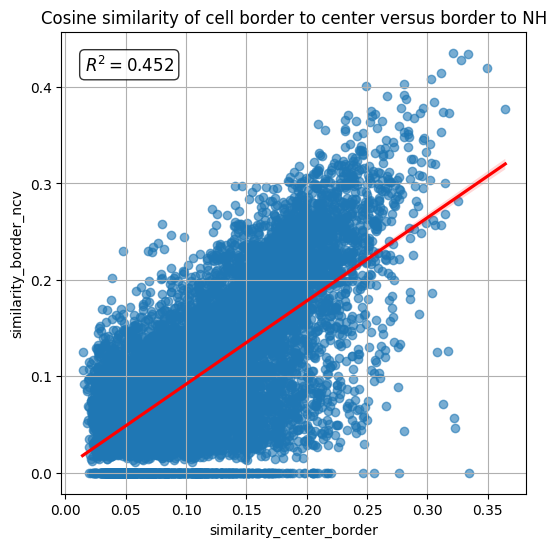

In [51]:
obs = sdata["table"].obs
# Extract the relevant columns, excluding NaNs
df = obs[["similarity_center_border", "similarity_border_neighborhood"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["similarity_center_border"], df["similarity_border_neighborhood"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="similarity_center_border",
    y="similarity_border_neighborhood",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("similarity_center_border")
ax.set_ylabel("similarity_border_ncv")
ax.set_title("Cosine similarity of cell border to center versus border to NH")
ax.grid(True)

plt.show()

The spatial plots below shows the spatial distribution of computed correlations. 

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                     

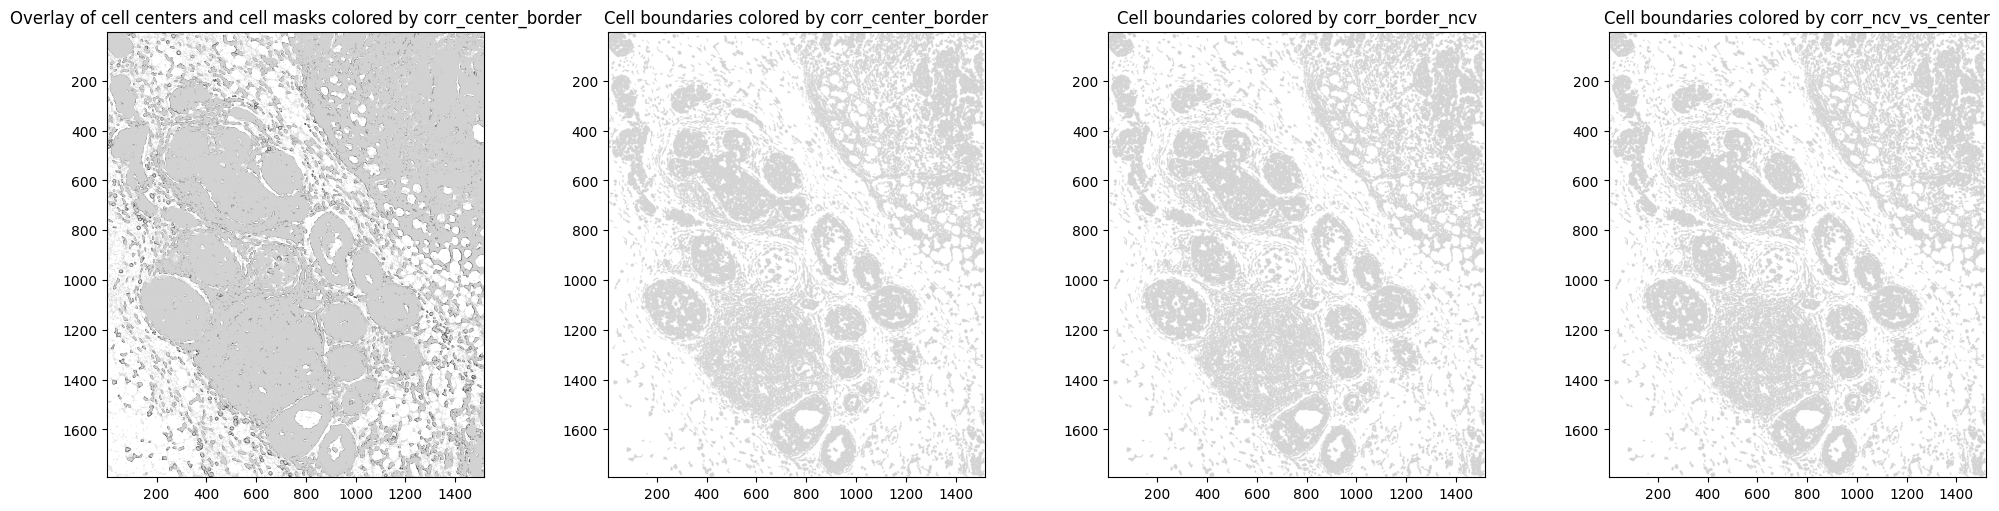

In [52]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_center_border",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["PTPRC"],
    palette=["red"],
).pl.show(
    ax=axes[0],
    title="Overlay of cell centers and cell masks colored by corr_center_border",
    colorbar=True,
    figsize=(6, 6),
)


sdata.pl.render_shapes("cell_boundaries", color="corr_center_border").pl.show(
    ax=axes[1], title="Cell boundaries colored by corr_center_border", coordinate_systems="global"
)

sdata.pl.render_shapes("cell_boundaries", color="corr_border_ncv").pl.show(
    ax=axes[2], title="Cell boundaries colored by corr_border_ncv", coordinate_systems="global"
)

sdata.pl.render_shapes("cell_boundaries", color="corr_ncv_vs_center").pl.show(
    ax=axes[3], title="Cell boundaries colored by corr_ncv_vs_center", coordinate_systems="global"
)

Let's investigate an example cell with one of the highest `corr_ncv_vs_center`.

In [ ]:
cid = obs.sort_values("corr_ncv_vs_center", ascending=False).iloc[6]["cell"]

We select one of the most highly abundant genes in this cell, `KRT7`. The plot below shows that KRT7 is distributed across the cell (yellow) border and its neighborhood, but absent from the cell center. 

In [ ]:
pix_to_um_scale_factor: float = 0.2125
centroid_x = obs.loc[obs["cell"] == cid, "centroid_x"].iloc[0] / pix_to_um_scale_factor
centroid_y = obs.loc[obs["cell"] == cid, "centroid_y"].iloc[0] / pix_to_um_scale_factor

print(f"The cell is located at ({centroid_x};{centroid_y})")

In [ ]:
tx = sdata.points["transcripts"].compute()
tx.loc[tx["assignment"] == cid, "gene"].value_counts()

In [ ]:
# add annotation of this cell to .obs
sdata["table"].obs["focal_cell"] = sdata["table"].obs["cell"] == cid

# plot cell and transcripts of that cell
axes = plt.subplots(1, 1, figsize=(16, 16), constrained_layout=True)[1]

sdata.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="focal_cell",
    fill_alpha=0.1,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="blue",
).pl.render_points(
    "transcripts",
    color="gene",
    fill_alpha=0.1,
    groups=["KRT7"],
    palette=["red"],
).pl.show(
    ax=axes,
    title="Cell with high corr_ncv_vs_center",
    colorbar=True,
    figsize=(10, 10),
)

All of the metrics are also stored in the spatialdata object.

In [ ]:
sdata.tables["table"]

In [ ]:
st.run_region_correlation()
sdata.tables["table"].obs.head()